In [1]:
import pandas as pd
import os

import tensorflow as tf
import tensorflow as tf
tf.config.set_visible_devices([], "GPU")  # ✅ désactive le GPU

# Charger le CSV
df = pd.read_csv("../data/dataset_selection_sans_leger.csv")

# Aperçu du dataset
print("Aperçu du dataset :")
print(df.head())

print("\nInformations générales :")
print(df.info())


2026-02-23 17:57:48.614397: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Aperçu du dataset :
                                                path     label
0  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
1  /home/mathis/Memoire/data/glaucome/ORIGA/ORIGA...  glaucome
2  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
3  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
4  /home/mathis/Memoire/data/glaucome/DRISHTI-GS/...  glaucome

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6047 entries, 0 to 6046
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   path    6047 non-null   object
 1   label   6047 non-null   object
dtypes: object(2)
memory usage: 94.6+ KB
None


In [15]:
print(f"Nombre total d'images : {len(df)}")
print(f"Nombre de colonnes : {df.shape[1]}")


Nombre total d'images : 6047
Nombre de colonnes : 2


In [16]:
# Compter le nombre d'images par label
class_counts = df['label'].value_counts()

print("\nRépartition des labels :")
print(class_counts)

# Pourcentage par label
class_percent = df['label'].value_counts(normalize=True) * 100
print("\nPourcentage par label :")
print(class_percent.round(2))



Répartition des labels :
label
mda         1552
glaucome    1500
diabete     1500
normaux     1495
Name: count, dtype: int64

Pourcentage par label :
label
mda         25.67
glaucome    24.81
diabete     24.81
normaux     24.72
Name: proportion, dtype: float64


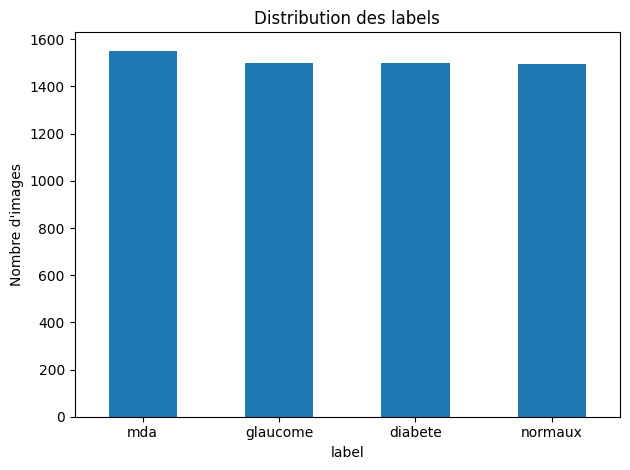

In [17]:
import matplotlib.pyplot as plt

class_counts.plot(kind='bar')
plt.title("Distribution des labels")
plt.xlabel("label")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [18]:
for classe in df['label'].unique():
    print(f"\nExemples pour la classe '{classe}' :")
    print(df[df['label'] == classe]['path'].head(3).tolist())



Exemples pour la classe 'glaucome' :
['/home/mathis/Memoire/data/glaucome/LAG/LAG/Training/glaucoma/1644.jpg', '/home/mathis/Memoire/data/glaucome/ORIGA/ORIGA/Training/glaucoma/383.jpg', '/home/mathis/Memoire/data/glaucome/LAG/LAG/Training/glaucoma/2747.jpg']

Exemples pour la classe 'mda' :
['/home/mathis/Memoire/data/mda/Fundus/Fundus/ARMD/161.png', '/home/mathis/Memoire/data/mda/Fundus/Fundus/ARMD/328.png', '/home/mathis/Memoire/data/mda/Fundus/Fundus/ARMD/235.png']

Exemples pour la classe 'diabete' :
['/home/mathis/Memoire/data/diabete/train.zip/train/25985_right.jpeg', '/home/mathis/Memoire/data/diabete/train.zip/train/38016_right.jpeg', '/home/mathis/Memoire/data/diabete/train.zip/train/20574_left.jpeg']

Exemples pour la classe 'normaux' :
['/home/mathis/Memoire/data/mda/ODIR-5K/ODIR-5K/Training Images/2598_right.jpg', '/home/mathis/Memoire/data/diabete/train.zip/train/6416_left.jpeg', '/home/mathis/Memoire/data/diabete/train.zip/train/13170_left.jpeg']


In [ ]:
from sklearn.model_selection import train_test_split

df_train, df_temp = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

df_test, df_val = train_test_split(
    df_temp,
    test_size=0.5,
    stratify=df_temp['label'],
    random_state=42
)

print("Tailles des splits :")
print(f"Train : {len(df_train)}")
print(f"Test : {len(df_test)}")
print(f"Validation : {len(df_val)}")

In [20]:
def show_distribution(name, data):
    print(f"\n{name}")
    print(data['label'].value_counts(normalize=True).round(3))

show_distribution("Train", df_train)
show_distribution("Test", df_test)
show_distribution("Validation", df_val)



Train
label
mda         0.257
diabete     0.248
glaucome    0.248
normaux     0.247
Name: proportion, dtype: float64

Test
label
mda         0.257
glaucome    0.248
diabete     0.248
normaux     0.247
Name: proportion, dtype: float64

Validation
label
mda         0.257
glaucome    0.248
diabete     0.248
normaux     0.248
Name: proportion, dtype: float64


In [21]:
import numpy as np

IMG_SIZE = (256, 256)
BATCH_SIZE = 32
SEED = 42

# mapping label -> id (si label est texte)
classes = sorted(df_train["label"].unique().tolist())
label_to_id = {c:i for i,c in enumerate(classes)}

def df_to_ds(df, shuffle=False):
    paths = df["path"].astype(str).values
    labels = df["label"].map(label_to_id).astype(int).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)

    def load_and_preprocess(path, label):
        img_bytes = tf.io.read_file(path)
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32)
        return img, label

    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    # ✅ ignore les fichiers qui cassent decode_image
    ds = ds.apply(tf.data.experimental.ignore_errors())

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = df_to_ds(df_train, shuffle=True)
val_ds   = df_to_ds(df_val, shuffle=False)
test_ds  = df_to_ds(df_test, shuffle=False)


In [9]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="aug")

#cnn
model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(256, 256, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(df['label'].unique()), activation='softmax')
])


early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
tf.config.optimizer.set_jit(False)   # désactive XLA globalement

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
    run_eagerly=True,   # ✅ évite graph/JIT => stoppe adam/Pow_* qui casse
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50


/home/mathis/Memoire/.venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    133/Unknown 102s 761ms/step - accuracy: 0.5096 - loss: 1.7685

2026-02-02 22:05:39.815436: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/home/mathis/Memoire/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


133/133 ━━━━━━━━━━━━━━━━━━━━ 108s 805ms/step - accuracy: 0.5640 - loss: 1.1298 - val_accuracy: 0.6784 - val_loss: 0.7834
Epoch 2/50


...

133/133 ━━━━━━━━━━━━━━━━━━━━ 105s 789ms/step - accuracy: 0.7013 - loss: 0.6680 - val_accuracy: 0.6795 - val_loss: 0.6692
Epoch 6/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 107s 802ms/step - accuracy: 0.7079 - loss: 0.6510 - val_accuracy: 0.6938 - val_loss: 0.6673
Epoch 7/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 104s 779ms/step - accuracy: 0.7202 - loss: 0.6255 - val_accuracy: 0.7170 - val_loss: 0.6231
Epoch 8/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 103s 776ms/step - accuracy: 0.7216 - loss: 0.6090 - val_accuracy: 0.7037 - val_loss: 0.6217
Epoch 9/50


2026-02-02 22:18:05.777590: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


133/133 ━━━━━━━━━━━━━━━━━━━━ 102s 766ms/step - accuracy: 0.7266 - loss: 0.6029 - val_accuracy: 0.7412 - val_loss: 0.6172
Epoch 10/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 101s 755ms/step - accuracy: 0.7344 - loss: 0.5852 - val_accuracy: 0.7280 - val_loss: 0.5811
Epoch 11/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 101s 761ms/step - accuracy: 0.7455 - loss: 0.5748 - val_accuracy: 0.6949 - val_loss: 0.6344
Epoch 12/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 104s 781ms/step - accuracy: 0.7524 - loss: 0.5634 - val_accuracy: 0.7269 - val_loss: 0.6068
Epoch 13/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 105s 788ms/step - accuracy: 0.7540 - loss: 0.5534 - val_accuracy: 0.7423 - val_loss: 0.5846
Epoch 14/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 107s 799ms/step - accuracy: 0.7583 - loss: 0.5482 - val_accuracy: 0.7500 - val_loss: 0.5701
Epoch 15/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 105s 786ms/step - accuracy: 0.7623 - loss: 0.5430 - val_accuracy: 0.7192 - val_loss: 0.5874
Epoch 16/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 107s 804ms/step - accuracy: 0.7677 - los

2026-02-02 22:31:57.129474: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


133/133 ━━━━━━━━━━━━━━━━━━━━ 105s 791ms/step - accuracy: 0.7656 - loss: 0.5177 - val_accuracy: 0.7324 - val_loss: 0.5769
Epoch 18/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 104s 779ms/step - accuracy: 0.7684 - loss: 0.5059 - val_accuracy: 0.7070 - val_loss: 0.6032
Epoch 19/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 100s 748ms/step - accuracy: 0.7701 - loss: 0.5085 - val_accuracy: 0.7423 - val_loss: 0.5715



=== Scores globaux ===
Accuracy            : 0.7354
Balanced accuracy   : 0.7348
Precision (macro)   : 0.7151
Recall (macro)      : 0.7348
F1 (macro)          : 0.7175
Precision (weighted): 0.7164
Recall (weighted)   : 0.7354
F1 (weighted)       : 0.7185

=== Rapport par classe ===
              precision    recall  f1-score   support

     diabete       0.70      0.88      0.78       225
    glaucome       0.85      0.98      0.91       225
         mda       0.83      0.75      0.79       233
     normaux       0.48      0.33      0.40       224

    accuracy                           0.74       907
   macro avg       0.72      0.73      0.72       907
weighted avg       0.72      0.74      0.72       907



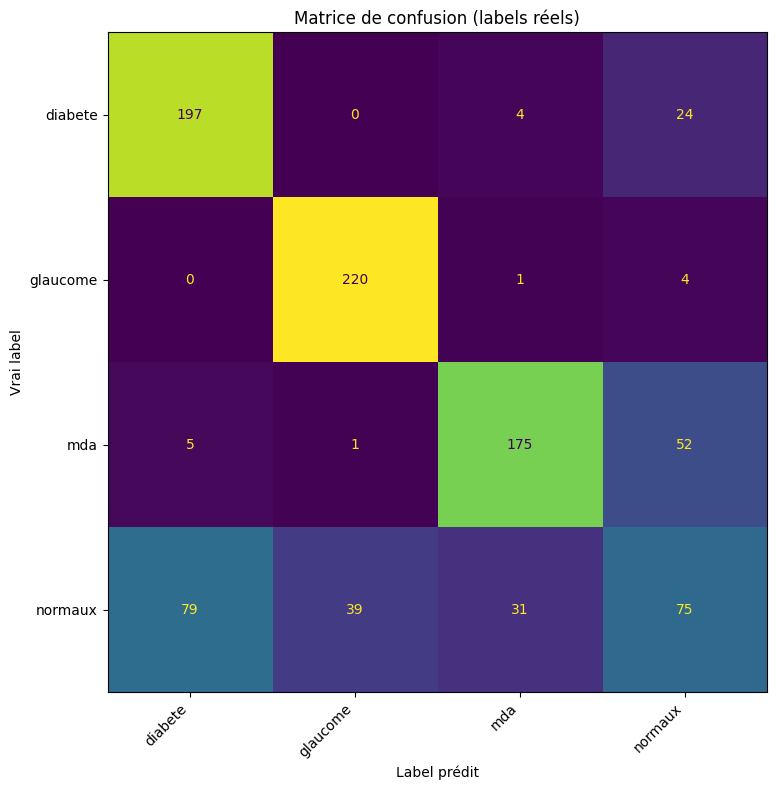

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report
)
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

proba = model.predict(test_ds, verbose=0)
y_pred = np.argmax(proba, axis=1)
num_classes = len(classes)

# ----------------------------
# 7) METRICS
# ----------------------------
acc = accuracy_score(y_true, y_pred)
bacc = balanced_accuracy_score(y_true, y_pred)

prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec_macro  = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro   = f1_score(y_true, y_pred, average="macro", zero_division=0)

prec_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
rec_weighted  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1_weighted   = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("\n=== Scores globaux ===")
print(f"Accuracy            : {acc:.4f}")
print(f"Balanced accuracy   : {bacc:.4f}")
print(f"Precision (macro)   : {prec_macro:.4f}")
print(f"Recall (macro)      : {rec_macro:.4f}")
print(f"F1 (macro)          : {f1_macro:.4f}")
print(f"Precision (weighted): {prec_weighted:.4f}")
print(f"Recall (weighted)   : {rec_weighted:.4f}")
print(f"F1 (weighted)       : {f1_weighted:.4f}")

print("\n=== Rapport par classe ===")
print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

# ----------------------------
# 8) CONFUSION MATRIX (labels réels, ordre forcé)
# ----------------------------
label_indices = list(range(num_classes))
cm = confusion_matrix(y_true, y_pred, labels=label_indices)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, values_format="d", cmap=None, colorbar=False)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.xlabel("Label prédit")
plt.ylabel("Vrai label")
plt.title("Matrice de confusion (labels réels)")
plt.tight_layout()
plt.show()


In [22]:
import numpy as np
from PIL import Image
def crop_black_border_pil(img: Image.Image, thr=10, pad=10):
    """
    img: PIL RGB
    thr: seuil (0-255). Plus haut => enlève plus (attention à ne pas rogner l'image utile)
    pad: marge ajoutée autour du crop
    """
    arr = np.array(img)  # H,W,3 uint8
    gray = arr.mean(axis=2)  # H,W

    mask = gray > thr  # True = zone utile
    if not mask.any():
        return img  # image totalement sombre -> on ne touche pas

    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()

    # padding + clamp aux bords
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(arr.shape[0] - 1, y1 + pad)
    x1 = min(arr.shape[1] - 1, x1 + pad)

    return img.crop((x0, y0, x1 + 1, y1 + 1))

In [23]:

def df_to_ds(df, shuffle=False):
    paths = df["path"].astype(str).values
    labels = df["label"].map(label_to_id).astype(int).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)

    def load_and_preprocess(path, label):
        def _py_load(p):
            p = p.numpy().decode("utf-8")
            img = Image.open(p).convert("RGB")
            img = crop_black_border_pil(img, thr=10, pad=10)
            img = img.resize(IMG_SIZE, Image.BILINEAR)
            return np.array(img, dtype=np.float32)

        img = tf.py_function(_py_load, [path], Tout=tf.float32)
        img.set_shape([256, 256, 3])  # shape fixe car resize déjà fait dans _py_load
        return img, label


    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    # ✅ ignore les fichiers qui cassent decode_image
    ds = ds.apply(tf.data.experimental.ignore_errors())

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = df_to_ds(df_train, shuffle=True)
val_ds   = df_to_ds(df_val, shuffle=False)
test_ds  = df_to_ds(df_test, shuffle=False)

In [24]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="aug")

#cnn
model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(256, 256, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(df['label'].unique()), activation='softmax')
])


early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
tf.config.optimizer.set_jit(False)   # désactive XLA globalement

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
    run_eagerly=True,   # ✅ évite graph/JIT => stoppe adam/Pow_* qui casse
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50


/home/mathis/Memoire/.venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    133/Unknown 208s 2s/step - accuracy: 0.4815 - loss: 1.7571

/home/mathis/Memoire/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


133/133 ━━━━━━━━━━━━━━━━━━━━ 242s 2s/step - accuracy: 0.5697 - loss: 1.1378 - val_accuracy: 0.6773 - val_loss: 0.7721
Epoch 2/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - accuracy: 0.6463 - loss: 0.8137 - val_accuracy: 0.6608 - val_loss: 0.7630
Epoch 3/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.6635 - loss: 0.7590 - val_accuracy: 0.6619 - val_loss: 0.6890
Epoch 4/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.6907 - loss: 0.7134 - val_accuracy: 0.6993 - val_loss: 0.6967
Epoch 5/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.7030 - loss: 0.6907 - val_accuracy: 0.6938 - val_loss: 0.7367
Epoch 6/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - accuracy: 0.7131 - loss: 0.6701 - val_accuracy: 0.7026 - val_loss: 0.6507
Epoch 7/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.7285 - loss: 0.6316 - val_accuracy: 0.7324 - val_loss: 0.6216
Epoch 8/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - accuracy: 0.7245 - loss: 0.6239 - val_accuracy: 0.699

2026-02-02 23:41:18.973231: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


133/133 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.7505 - loss: 0.5581 - val_accuracy: 0.7346 - val_loss: 0.5758
Epoch 14/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.7599 - loss: 0.5647 - val_accuracy: 0.7434 - val_loss: 0.5531
Epoch 15/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 229s 2s/step - accuracy: 0.7606 - loss: 0.5492 - val_accuracy: 0.7456 - val_loss: 0.5653
Epoch 16/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.7616 - loss: 0.5549 - val_accuracy: 0.7324 - val_loss: 0.5995
Epoch 17/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 229s 2s/step - accuracy: 0.7604 - loss: 0.5455 - val_accuracy: 0.7335 - val_loss: 0.5694
Epoch 18/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.7717 - loss: 0.5234 - val_accuracy: 0.7423 - val_loss: 0.5826
Epoch 19/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.7639 - loss: 0.5359 - val_accuracy: 0.7412 - val_loss: 0.5390
Epoch 20/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.7736 - loss: 0.5189 - val_accuracy


=== Scores globaux ===
Accuracy            : 0.7652
Balanced accuracy   : 0.7637
Precision (macro)   : 0.7504
Recall (macro)      : 0.7637
F1 (macro)          : 0.7514
Precision (weighted): 0.7507
Recall (weighted)   : 0.7652
F1 (weighted)       : 0.7523

=== Rapport par classe ===
              precision    recall  f1-score   support

     diabete       0.75      0.85      0.80       225
    glaucome       0.90      0.92      0.91       225
         mda       0.77      0.88      0.82       233
     normaux       0.58      0.40      0.47       224

    accuracy                           0.77       907
   macro avg       0.75      0.76      0.75       907
weighted avg       0.75      0.77      0.75       907



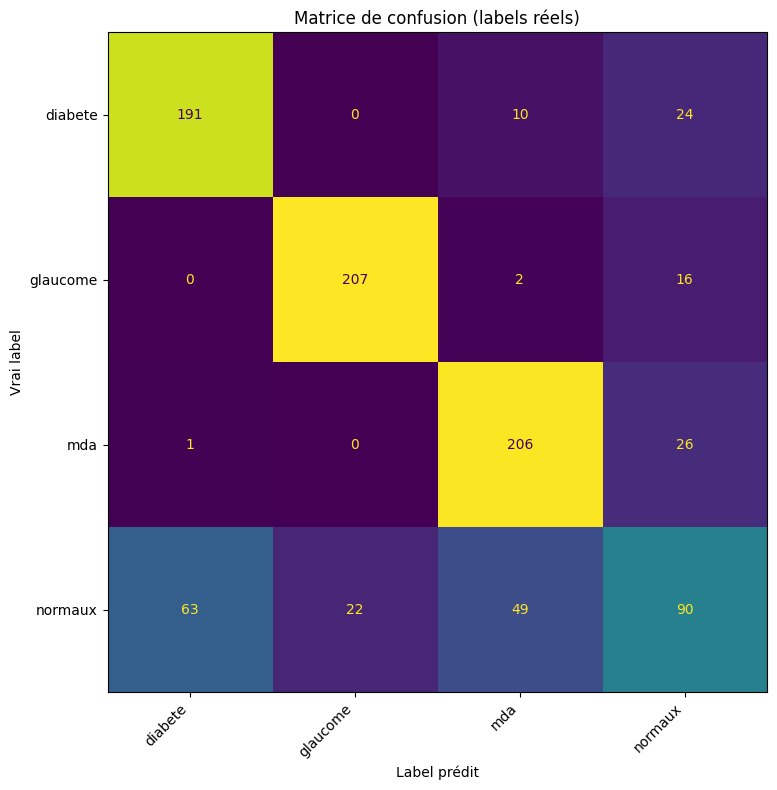

In [25]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report
)
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

proba = model.predict(test_ds, verbose=0)
y_pred = np.argmax(proba, axis=1)
num_classes = len(classes)

# ----------------------------
# 7) METRICS
# ----------------------------
acc = accuracy_score(y_true, y_pred)
bacc = balanced_accuracy_score(y_true, y_pred)

prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec_macro  = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro   = f1_score(y_true, y_pred, average="macro", zero_division=0)

prec_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
rec_weighted  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1_weighted   = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("\n=== Scores globaux ===")
print(f"Accuracy            : {acc:.4f}")
print(f"Balanced accuracy   : {bacc:.4f}")
print(f"Precision (macro)   : {prec_macro:.4f}")
print(f"Recall (macro)      : {rec_macro:.4f}")
print(f"F1 (macro)          : {f1_macro:.4f}")
print(f"Precision (weighted): {prec_weighted:.4f}")
print(f"Recall (weighted)   : {rec_weighted:.4f}")
print(f"F1 (weighted)       : {f1_weighted:.4f}")

print("\n=== Rapport par classe ===")
print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

# ----------------------------
# 8) CONFUSION MATRIX (labels réels, ordre forcé)
# ----------------------------
label_indices = list(range(num_classes))
cm = confusion_matrix(y_true, y_pred, labels=label_indices)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, values_format="d", cmap=None, colorbar=False)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.xlabel("Label prédit")
plt.ylabel("Vrai label")
plt.title("Matrice de confusion (labels réels)")
plt.tight_layout()
plt.show()
